# 04_02 Classification - RandomForest
Train and evaluate RandomForestClassifier.

[COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]
- Muc tieu nghiep vu: Train RandomForestClassifier va visual output tren test set.
- Muc tieu ky thuat: Hien thi bang metric va confusion matrix ngay trong notebook.

Before oversampling: class_0=52584, class_1=17025, ratio=3.09
After oversampling: 105187 rows


26/04/05 18:18:08 WARN DAGScheduler: Broadcasting large task binary with size 1500.0 KiB
26/04/05 18:18:16 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/04/05 18:18:24 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/04/05 18:18:34 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
26/04/05 18:18:41 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
26/04/05 18:18:47 WARN DAGScheduler: Broadcasting large task binary with size 6.8 MiB
26/04/05 18:18:53 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/04/05 18:18:53 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/04/05 18:18:54 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/04/05 18:18:55 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/04/05 18:18:56 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/04/05 18:18:57 WARN DAGScheduler: Broadcasting l

Val   => F1: 0.8318, Accuracy: 0.8323, Precision: 0.8314, Recall: 0.8323
Test  => F1: 0.8418, Accuracy: 0.8411, Precision: 0.8425, Recall: 0.8411
{'model_family': 'classification', 'model_name': 'RandomForestClassifier', 'val_f1': 0.8318447555986237, 'val_accuracy': 0.8323277017967283, 'val_precision': 0.831378703398949, 'val_recall': 0.8323277017967283, 'f1': 0.8418026620761125, 'accuracy': 0.8411102172164119, 'precision': 0.84252886931441, 'recall': 0.8411102172164119, 'test_f1': 0.8418026620761125, 'test_accuracy': 0.8411102172164119, 'test_precision': 0.84252886931441, 'test_recall': 0.8411102172164119, 'train_rows': 105187, 'val_rows': 14916, 'test_rows': 14916}


,model_family,model_name,val_f1,val_accuracy,val_precision,val_recall,f1,accuracy,precision,recall,test_f1,test_accuracy,test_precision,test_recall,train_rows,val_rows,test_rows
0,classification,RandomForestClassifier,0.831845,0.832328,0.831379,0.832328,0.841803,0.84111,0.842529,0.84111,0.841803,0.84111,0.842529,0.84111,105187,14916,14916


26/04/05 18:18:59 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/04/05 18:19:00 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB


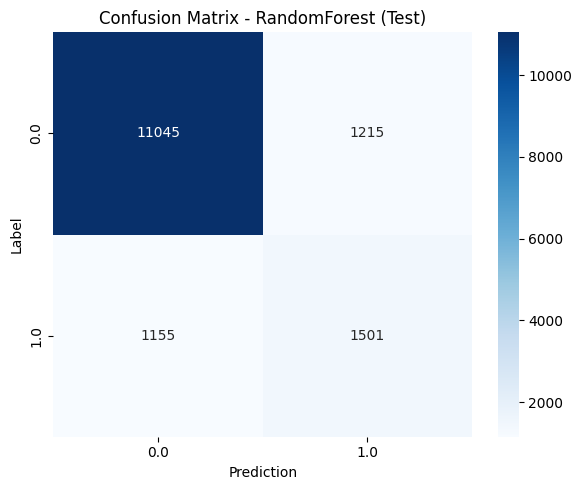

26/04/05 18:19:01 WARN TaskSetManager: Stage 144 contains a task of very large size (2024 KiB). The maximum recommended task size is 1000 KiB.


565

In [2]:
from pathlib import Path
import json
from pyspark.sql import SparkSession
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
spark=(SparkSession.builder.appName('04_02_rf_cls').master('local[2]').config('spark.sql.shuffle.partitions','16').getOrCreate())
spark.sparkContext.setLogLevel('WARN')
PROJECT_ROOT=Path.cwd().resolve().parent if Path.cwd().name=='notebooks' else Path.cwd().resolve()
FEATURE_DIR=PROJECT_ROOT/'data'/'processed'/'features'
MODEL_DIR=PROJECT_ROOT/'models'/'classification'/'random_forest'
METRIC_DIR=PROJECT_ROOT/'reports'/'model_metrics'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
train_df=spark.read.parquet(str(FEATURE_DIR/'classification_train')).select('order_id','label','features').dropna()
# --- Oversample minority class (class 1) to handle class imbalance ---
_c0 = train_df.filter(train_df['label'] == 0)
_c1 = train_df.filter(train_df['label'] == 1)
_n0, _n1 = _c0.count(), _c1.count()
print(f'Before oversampling: class_0={_n0}, class_1={_n1}, ratio={_n0/_n1:.2f}')
train_df = _c0.unionAll(_c1.sample(withReplacement=True, fraction=_n0/_n1, seed=42))
print(f'After oversampling: {train_df.count()} rows')
val_df=spark.read.parquet(str(FEATURE_DIR/'classification_val')).select('order_id','label','features').dropna()
test_df=spark.read.parquet(str(FEATURE_DIR/'classification_test')).select('order_id','label','features').dropna()
rf=RandomForestClassifier(featuresCol='features',labelCol='label',numTrees=120,maxDepth=12,seed=42)
m=rf.fit(train_df)
pred_val=m.transform(val_df)
pred_test=m.transform(test_df)
val_f1=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='f1').evaluate(pred_val)
val_acc=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='accuracy').evaluate(pred_val)
test_f1=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='f1').evaluate(pred_test)
test_acc=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='accuracy').evaluate(pred_test)
val_precision = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedPrecision').evaluate(pred_val)
val_recall    = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedRecall').evaluate(pred_val)
test_precision = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedPrecision').evaluate(pred_test)
test_recall    = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedRecall').evaluate(pred_test)
metrics={
    'model_family':'classification',
    'model_name':'RandomForestClassifier',
    'val_f1':float(val_f1),
    'val_accuracy':float(val_acc),
    'val_precision': float(val_precision),
    'val_recall':    float(val_recall),
    'f1':float(test_f1),
    'accuracy':float(test_acc),
    'precision': float(test_precision),
    'recall':    float(test_recall),
    'test_f1':float(test_f1),
    'test_accuracy':float(test_acc),
    'test_precision': float(test_precision),
    'test_recall':    float(test_recall),
    'train_rows':train_df.count(),
    'val_rows':val_df.count(),
    'test_rows':test_df.count()
}
print(f"Val   => F1: {metrics['val_f1']:.4f}, Accuracy: {metrics['val_accuracy']:.4f}, Precision: {metrics['val_precision']:.4f}, Recall: {metrics['val_recall']:.4f}")
print(f"Test  => F1: {metrics['f1']:.4f}, Accuracy: {metrics['accuracy']:.4f}, Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f}")
print(metrics)
display(pd.DataFrame([metrics]))
cm_pdf=pred_test.groupBy('label','prediction').count().toPandas()
if not cm_pdf.empty:
    cm_table=cm_pdf.pivot(index='label', columns='prediction', values='count').fillna(0).sort_index().sort_index(axis=1)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_table, annot=True, fmt='.0f', cmap='Blues')
    plt.title('Confusion Matrix - RandomForest (Test)')
    plt.xlabel('Prediction')
    plt.ylabel('Label')
    plt.tight_layout()
    plt.show()
m.write().overwrite().save(str(MODEL_DIR))
(METRIC_DIR/'classification_random_forest.json').write_text(json.dumps(metrics,indent=2),encoding='utf-8')